# 🔧 Setup dataset (dùng chung cho tất cả)

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

n = 1000
df = pd.DataFrame({
    "customer_id": np.random.randint(1, 300, n),
    "order_value": np.random.exponential(100, n),
    "discount": np.random.uniform(0, 0.3, n),
    "device": np.random.choice(["mobile", "desktop"], n, p=[0.7, 0.3]),
    "region": np.random.choice(["A", "B", "C"], n),
    "date": pd.date_range(start="2024-01-01", periods=n, freq="D")
})

df["converted"] = (df["order_value"] > 80).astype(int)
df["month"] = df["date"].dt.to_period("M")

In [26]:
df2 = sns.load_dataset("penguins")
df3 = sns.load_dataset("tips")

In [45]:
df.head()

,customer_id,order_value,discount,device,region,date,converted,month
0,103,83.204410,0.252600,mobile,B,2024-01-01,1,2024-01
1,271,6.796694,0.218547,mobile,A,2024-01-02,0,2024-01
2,107,149.400259,0.232934,desktop,A,2024-01-03,1,2024-01
3,72,60.383465,0.196849,mobile,A,2024-01-04,0,2024-01
4,189,74.315765,0.053229,desktop,C,2024-01-05,0,2024-01


# I. 📊 DESCRIPTIVE — “What happened?”

👉 Câu hỏi: “What happened?”

1. Summary statistics
- Mean / Median / Mode
- Min / Max
- Std / Variance
- Distribution shape (skew, kurtosis)

➡️ Insight kiểu:

“Doanh thu bị skew mạnh → phụ thuộc vào top customers”

In [35]:
df["order_value"].describe()

count    1000.000000
mean      101.287412
std       102.208078
min         0.495222
25%        27.098910
50%        71.018328
75%       140.690152
max       744.172291
Name: order_value, dtype: float64

In [36]:
df['order_value'].mean()

101.28741160788232

In [37]:
df['order_value'].median()

71.01832788721168

In [42]:
df['order_value'].mode()

0        0.495222
1        0.577531
2        0.640635
3        0.759162
4        0.981890
          ...    
995    560.863123
996    571.287989
997    585.152876
998    618.219441
999    744.172291
Length: 1000, dtype: float64

In [43]:
df['order_value'].skew()

1.92524383868541

- Skewness > 0: Right-skewed (positive tail)
- Skewness < 0: Left-skewed (negative tail)
- Skewness = 0: Symmetric (like a normal distribution)

In [44]:
df['order_value'].kurt()

4.936591454409317

- Kurtosis	> 0	Leptokurtic: Heavy tails, more outliers
- (Excess)	< 0	Platykurtic: Light tails, fewer outliers
- (Excess)  ≈ 0	Mesokurtic: Normal distribution tail behavior

2. Distribution analysis
- Histogram
- Boxplot
- Density plot

➡️ Insight:

- Outliers
- Long tail behavior
- Data imbalance

In [20]:
df2.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


<AxesSubplot:xlabel='flipper_length_mm', ylabel='Count'>

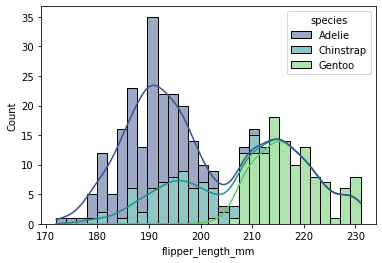

In [25]:
sns.histplot(
    data=df2, 
    x="flipper_length_mm", 
    hue="species",      # Color by category
    kde=True,           # Add smooth density line
    bins=30,            # Specify number of bins
    multiple="stack",   # Options: "layer", "stack", "dodge"
    palette="viridis"   # Choose a color palette
)

<AxesSubplot:xlabel='species', ylabel='flipper_length_mm'>

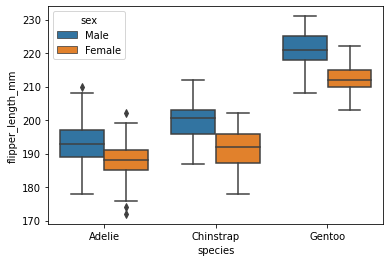

In [24]:
sns.boxplot(data=df2, x="species", y="flipper_length_mm", hue="sex")

<AxesSubplot:xlabel='total_bill', ylabel='tip'>

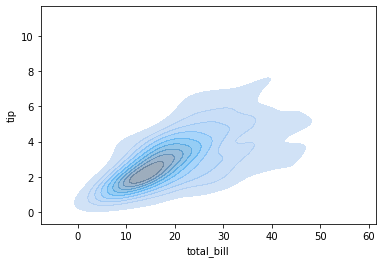

In [33]:
sns.kdeplot(data=df3, x="total_bill", y="tip", fill=True, alpha=0.5)

<AxesSubplot:xlabel='total_bill', ylabel='tip'>

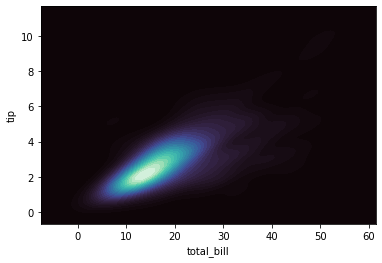

In [32]:
sns.kdeplot(data=df3, x="total_bill", y="tip", fill=True, thresh=0, levels=30, cmap="mako")

3. Segmentation (cực kỳ quan trọng)

Theo:
- Customer (VIP / churn risk)
- Region
- Product
- Time cohort

➡️ Insight:

“80% revenue đến từ 20% khách hàng (Pareto)”

In [46]:
df.groupby("customer_id")["order_value"].sum().sort_values(ascending=False).head(10)

customer_id
233    1706.868844
122    1398.750772
277    1319.919772
154    1306.485647
152    1283.568172
217    1241.967793
113    1186.466743
25     1143.268983
39     1087.939281
237    1076.184371
Name: order_value, dtype: float64

# II. ⚖️ COMPARISON — “What is different?”

👉 “What is different?”

4. A vs B comparison
- Before vs After
- Group A vs Group B

➡️ Insight:

“Campaign tăng conversion +15%”

In [47]:
df.groupby("device")["converted"].mean()

device
desktop    0.449324
mobile     0.463068
Name: converted, dtype: float64

👉 Insight:

Mobile conversion thấp hơn desktop

5. Benchmarking
So với:
- Target
- Historical
- Industry

➡️ Insight:

“Retention thấp hơn benchmark ngành 10%”

In [48]:
current = df["converted"].mean()
target = 0.6

print(current - target)

-0.14099999999999996


👉 Insight:

Conversion thấp hơn target

6. Ranking & contribution
- Top / Bottom analysis
- Contribution %

➡️ Insight:

“Top 3 product chiếm 65% revenue”

In [49]:
top_products = df.groupby("customer_id")["order_value"].sum()
top_products = top_products / top_products.sum()
top_products.sort_values(ascending=False).head(5)

customer_id
233    0.016852
122    0.013810
277    0.013031
154    0.012899
152    0.012673
Name: order_value, dtype: float64

👉 Insight:

Pareto 80/20

# III. 📈 TIME-BASED — “What changed?”

👉 “What changed over time?”

7. Trend analysis

Time series (daily / weekly / monthly)

➡️ Insight:

“Doanh thu giảm đều từ Q2 → dấu hiệu vấn đề dài hạn”

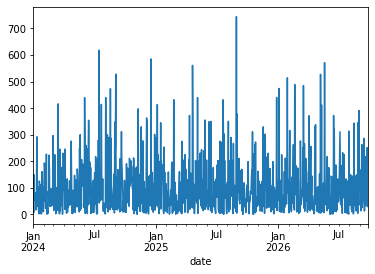

In [50]:
df.groupby("date")["order_value"].sum().plot()
plt.show()

👉 Insight:

Trend giảm / tăng theo thời gian

8. Seasonality

Pattern lặp lại

➡️ Insight:

“Peak sales vào cuối tháng”

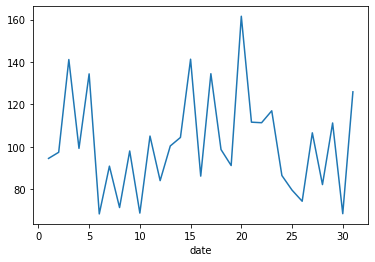

In [51]:
df.groupby(df["date"].dt.day)["order_value"].mean().plot()
plt.show()

👉 Insight:

Pattern theo ngày trong tháng

9. Cohort analysis

Nhóm user theo thời điểm join

➡️ Insight:

“User mới churn nhanh hơn user cũ”

In [63]:
df["cohort"] = df.groupby("customer_id")["date"].transform("min").dt.to_period("M")
cohort = df.groupby(["cohort", "month"])["customer_id"].nunique().unstack()

In [64]:
cohort.reset_index()

month,cohort,2024-01,2024-02,2024-03,2024-04,2024-05,2024-06,2024-07,2024-08,2024-09,...,2025-12,2026-01,2026-02,2026-03,2026-04,2026-05,2026-06,2026-07,2026-08,2026-09
0,2024-01,29.0,4.0,2.0,1.0,2.0,1.0,1.0,3.0,5.0,...,2.0,2.0,4.0,NaN,2.0,NaN,1.0,1.0,3.0,5.0
1,2024-02,NaN,25.0,3.0,2.0,1.0,5.0,NaN,2.0,3.0,...,2.0,3.0,1.0,NaN,3.0,2.0,NaN,3.0,2.0,NaN
2,2024-03,NaN,NaN,24.0,4.0,2.0,1.0,4.0,3.0,2.0,...,1.0,3.0,1.0,NaN,3.0,4.0,6.0,NaN,2.0,1.0
3,2024-04,NaN,NaN,NaN,22.0,2.0,4.0,2.0,2.0,2.0,...,4.0,2.0,2.0,1.0,3.0,5.0,4.0,3.0,4.0,1.0
4,2024-05,NaN,NaN,NaN,NaN,22.0,5.0,4.0,3.0,3.0,...,2.0,4.0,2.0,4.0,3.0,5.0,1.0,3.0,2.0,2.0
5,2024-06,NaN,NaN,NaN,NaN,NaN,8.0,NaN,1.0,1.0,...,2.0,1.0,1.0,2.0,1.0,1.0,NaN,1.0,1.0,1.0
6,2024-07,NaN,NaN,NaN,NaN,NaN,NaN,17.0,1.0,2.0,...,NaN,1.0,1.0,1.0,1.0,1.0,3.0,1.0,1.0,2.0
7,2024-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.0,NaN,...,NaN,NaN,1.0,3.0,1.0,2.0,1.0,2.0,1.0,NaN
8,2024-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.0,...,NaN,2.0,2.0,2.0,1.0,NaN,1.0,1.0,1.0,1.0
9,2024-10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.0,1.0,2.0,2.0,2.0,1.0,NaN,2.0,NaN,NaN


👉 Insight:

User mới churn nhanh

# IV. 🔗 RELATIONSHIP — “Why?”

👉 “Why is this happening?”

10. Correlation analysis
Pearson / Spearman

➡️ Insight:

“Discount càng cao → revenue không tăng tương ứng”

In [65]:
df[["order_value", "discount"]].corr()

,order_value,discount
order_value,1.000000,0.053328
discount,0.053328,1.000000


👉 Insight:

Discount tăng nhưng revenue không tăng tương ứng

11. Scatter plot analysis

Nhìn pattern trực quan

➡️ Insight:

Linear / nonlinear relationship
Cluster

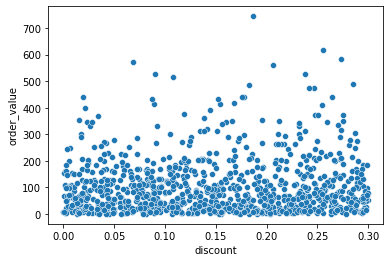

In [66]:
sns.scatterplot(data=df, x="discount", y="order_value")
plt.show()

👉 Insight:

Không có linear relationship rõ

12. Feature interaction

X kết hợp Y

➡️ Insight:

“Khách trẻ + mobile → churn cao”

In [68]:
df.groupby(["device", "region"])["converted"].mean()

device   region
desktop  A         0.463918
         B         0.431818
         C         0.450450
mobile   A         0.428571
         B         0.475610
         C         0.481328
Name: converted, dtype: float64

👉 Insight:

Mobile + region A → conversion thấp

# V. 📊 STATISTICAL INFERENCE — “Real or random?”

👉 “Is this real or random?”

13. Hypothesis testing
- t-test
- chi-square
- ANOVA

➡️ Insight:

“Sự khác biệt conversion là statistically significant”

In [69]:
from scipy.stats import ttest_ind

mobile = df[df["device"]=="mobile"]["converted"]
desktop = df[df["device"]=="desktop"]["converted"]

ttest_ind(mobile, desktop)

Ttest_indResult(statistic=0.3977732262286398, pvalue=0.6908824209767466)

👉 Insight:

p < 0.05 → khác biệt có ý nghĩa

14. Confidence interval

➡️ Insight:

“Conversion thực tế nằm trong khoảng 12%–15%”

In [70]:
import statsmodels.api as sm

ci = sm.stats.proportion_confint(df["converted"].sum(), len(df))
ci

(0.42811461166026976, 0.4898853883397303)

👉 Insight:

Conversion nằm trong khoảng X–Y

15. A/B Testing

➡️ Insight:

“Variant B tốt hơn A với p-value < 0.05”

In [71]:
df["variant"] = np.random.choice(["A", "B"], len(df))
df.groupby("variant")["converted"].mean()

variant
A    0.449597
B    0.468254
Name: converted, dtype: float64

# VI. 🔍 FUNNEL & BEHAVIOR ANALYSIS

👉 “Where is the problem?”

16. Funnel analysis

Step drop-off

➡️ Insight:

“70% user rơi ở bước payment”

In [73]:
funnel = pd.DataFrame({
    "step": ["visit", "add_to_cart", "checkout", "purchase"],
    "users": [1000, 600, 300, 150]
})

funnel["drop_rate"] = funnel["users"].pct_change()

In [74]:
funnel

,step,users,drop_rate
0,visit,1000,NaN
1,add_to_cart,600,-0.4
2,checkout,300,-0.5
3,purchase,150,-0.5


👉 Insight:

Drop mạnh ở checkout

17. User journey

Flow / path

➡️ Insight:

“User thường bỏ app sau khi search”

In [75]:
df["device"].value_counts()

mobile     704
desktop    296
Name: device, dtype: int64

👉 Insight:

Mobile dominate

18. Retention / churn analysis

➡️ Insight:

“User churn mạnh ở ngày thứ 7”

In [76]:
retention = df.groupby("customer_id")["date"].count()
retention

customer_id
1      8
2      3
3      1
4      4
5      7
      ..
295    2
296    4
297    1
298    1
299    2
Name: date, Length: 284, dtype: int64

👉 Insight:

User activity thấp → churn

# VII. 🧠 ROOT CAUSE

👉 “Why exactly?”

19. Drill-down

Slice data theo dimension

In [77]:
df.groupby(["region", "device"])["converted"].mean()

region  device 
A       desktop    0.463918
        mobile     0.428571
B       desktop    0.431818
        mobile     0.475610
C       desktop    0.450450
        mobile     0.481328
Name: converted, dtype: float64

20. 80/20 (Pareto)

➡️ Insight:

“Vấn đề đến từ 1 nhóm nhỏ nhưng ảnh hưởng lớn”

In [78]:
revenue = df.groupby("customer_id")["order_value"].sum().sort_values(ascending=False)
cum = revenue.cumsum() / revenue.sum()

In [79]:
cum

customer_id
233    0.016852
122    0.030661
277    0.043693
154    0.056592
152    0.069264
         ...   
287    0.999835
169    0.999894
11     0.999932
40     0.999969
278    1.000000
Name: order_value, Length: 284, dtype: float64

👉 Insight:

20% khách tạo 80% revenue

21. Cohort + segmentation kết hợp

➡️ Insight:

“Churn đến từ user mới ở region A”

# VIII. 🤖 MODELING

👉 “What will happen / what drives it?”

22. Regression

➡️ Insight:

“Price là yếu tố ảnh hưởng mạnh nhất đến demand”

In [80]:
import statsmodels.formula.api as smf

model = smf.ols("order_value ~ discount", data=df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            order_value   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     2.846
Date:                Tue, 21 Apr 2026   Prob (F-statistic):             0.0919
Time:                        10:33:55   Log-Likelihood:                -6044.0
No. Observations:                1000   AIC:                         1.209e+04
Df Residuals:                     998   BIC:                         1.210e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     91.8959      6.435     14.280      0.0

👉 Insight:

Discount ảnh hưởng yếu

23. Classification

Predict churn / conversion

In [81]:
from sklearn.linear_model import LogisticRegression

X = df[["discount"]]
y = df["converted"]

model = LogisticRegression().fit(X, y)

LogisticRegression()

24. Clustering

➡️ Insight:

“Có 4 nhóm khách hàng với behavior khác nhau”

In [83]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3)
df["cluster"] = kmeans.fit_predict(df[["order_value", "discount"]])

In [88]:
df.groupby('cluster')['customer_id'].count()

cluster
0    591
1     84
2    325
Name: customer_id, dtype: int64

👉 Insight:

3 nhóm khách khác nhau

25. Feature importance

➡️ Insight:

“Time on site quan trọng hơn discount”

# IX. 🚨 ANOMALY & PATTERN DISCOVERY

👉 “What is unusual?”

26. Outlier detection

➡️ Insight:

“Spike bất thường ngày 15”

In [89]:
q1 = df["order_value"].quantile(0.25)
q3 = df["order_value"].quantile(0.75)
iqr = q3 - q1

outliers = df[df["order_value"] > q3 + 1.5*iqr]

In [91]:
outliers.head()

,customer_id,order_value,discount,device,region,date,converted,month,cohort,variant,cluster
74,65,416.062416,0.168198,mobile,B,2024-03-15,1,2024-03,2024-03,B,1
153,172,439.555842,0.018796,mobile,B,2024-06-02,1,2024-06,2024-04,A,1
165,113,354.246992,0.015677,mobile,C,2024-06-14,1,2024-06,2024-06,B,1
196,187,618.219441,0.254993,mobile,B,2024-07-15,1,2024-07,2024-05,A,1
203,128,414.039704,0.153751,mobile,C,2024-07-22,1,2024-07,2024-05,A,1


27. Change point detection

➡️ Insight:

“Doanh thu bắt đầu giảm từ khi thay UI”

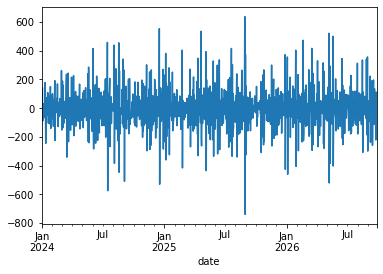

In [92]:
df.groupby("date")["order_value"].sum().diff().plot()
plt.show()

# X. 🧹 DATA QUALITY

28. Missing data
29. Duplicates
30. Bias detection

➡️ Insight:

“Data bị bias → insight trước đó sai”

In [93]:
df.isnull().sum()

customer_id    0
order_value    0
discount       0
device         0
region         0
date           0
converted      0
month          0
cohort         0
variant        0
cluster        0
dtype: int64

In [94]:
df.duplicated().sum()

0

# XI. NHÓM 11 — STORYTELLING (QUAN TRỌNG NHẤT)

👉 Insight không phải là số — mà là câu chuyện

Framework phổ biến:
- What → So what → Now what
- Problem → Cause → Action
- Signal vs Noise

👉 Ví dụ chuẩn:

What

Conversion mobile thấp hơn desktop 15%

So what

Mất revenue lớn vì 70% traffic là mobile

Now what

Tối ưu UX checkout mobile

🚀 BONUS — CÁCH DÙNG TRONG PHỎNG VẤN

Bạn có thể nói cực mạnh kiểu này:

“I usually approach analysis in 3 layers:

- Descriptive → understand what happened
- Diagnostic → find why
- Prescriptive → recommend action”

⚠️ GÓC THẲNG (quan trọng)

Sai lầm phổ biến:

- Chỉ dừng ở mean / chart
- Không drill-down
- Không kiểm định thống kê
- Không đưa action

👉 Insight KHÔNG phải:

“Biểu đồ cho thấy A cao hơn B”

👉 Insight ĐÚNG:

“A cao hơn B → ảnh hưởng X → cần làm Y”